IMPORTS


In [52]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import warnings
import shap
warnings.filterwarnings('ignore')



In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,precision_recall_curve,precision_score,f1_score,classification_report,roc_curve
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

DATAPREPROCESSING

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
*******************************
MISING VALUES ARE NOW REPLACED MY NAN
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


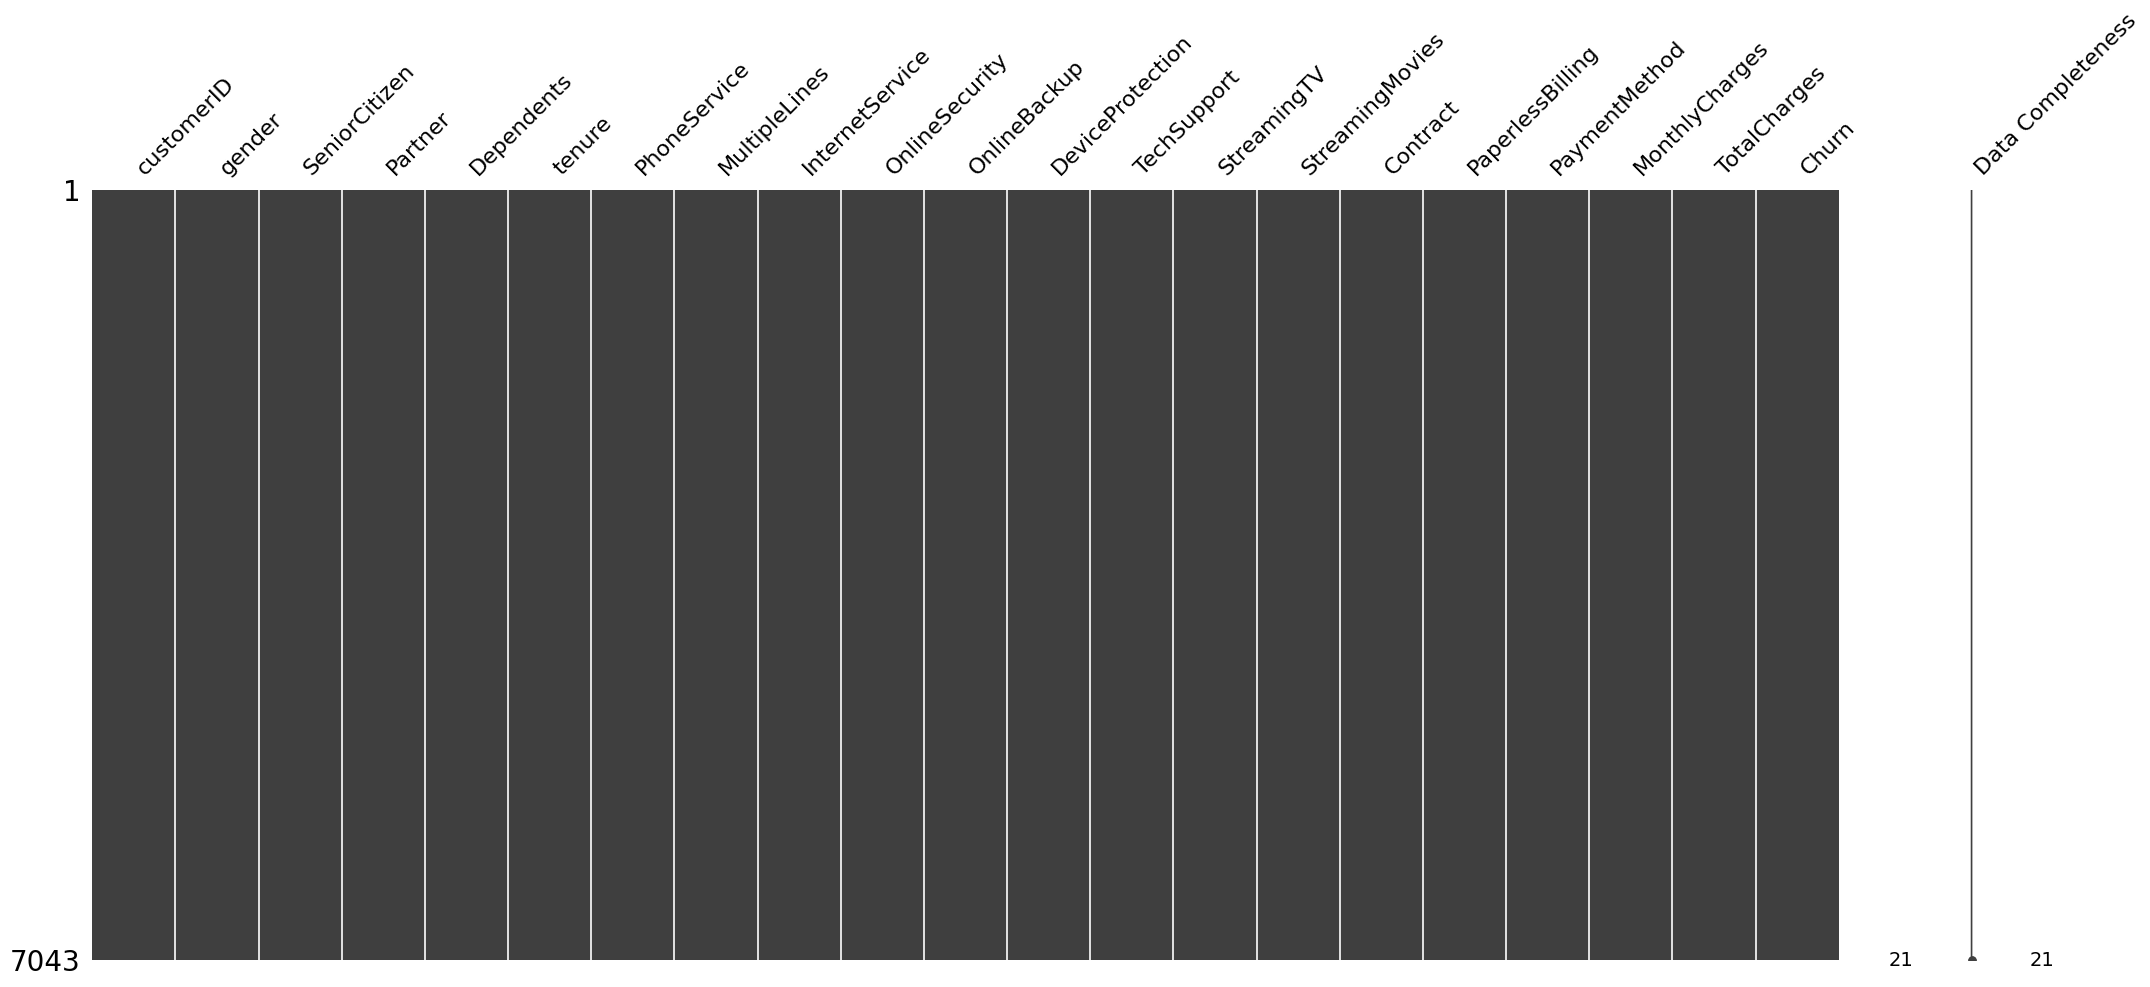

In [56]:
class DataPreprocessing:
    def __init__(self):
        pass
    
    def forward(self, path):
        df = pd.read_csv(path)
        # print("CHECKING OF MISSING VALUES OR UNSPECIFIED DATA")
        msno.matrix(df,labels = "CHECKING FOR MISSING VALUES")
        df = df.drop(['customerID'], axis=1)
        
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
        print(df.isnull().sum())
        
        
        # Drop rows where 'tenure' is 0
        df = df[df['tenure'] != 0]
        
        # Fill NaN values in 'TotalCharges' with the mean of 'TotalCharges'
        df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
        
        # Check for any remaining missing values
        missing_values = df.isnull().sum()
        print("*******************************")
        print("MISING VALUES ARE NOW REPLACED MY NAN")
        print(missing_values)
        
        # Map 'SeniorCitizen' from 0, 1 to 'No', 'Yes'
        df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
        
        return df
            
dp = DataPreprocessing()
df= dp.forward('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()      

EDA(Numerical and Labelled)

In [6]:
print(df["InternetService"].describe(include=['object','bool']))

'''count: The number of non-null entries.
unique: The number of unique values.
top: The most common value.
freq: The most common value's frequency.'''

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object


"count: The number of non-null entries.\nunique: The number of unique values.\ntop: The most common value.\nfreq: The most common value's frequency."

In [7]:
numerical_cols = ['tenure' ,'MonthlyCharges','TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [8]:
df["Churn"][df["Churn"]=="No"].groupby(by=df["gender"]).count() 

gender
Female    2544
Male      2619
Name: Churn, dtype: int64

In [9]:
df["Churn"][df["Churn"]=="Yes"].groupby(by=df["gender"]).count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

In [10]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [11]:
df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       992
Fiber optic      No       910
No               No       717
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [12]:

df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       965
Fiber optic      No       889
No               No       690
Fiber optic      Yes      664
DSL              Yes      219
No               Yes       56
Name: count, dtype: int64

DATA_VISUALIZATION AND EDA(Labelled)

In [13]:

class ChurnAnalysis:
    def __init__(self, df):
        self.df = df
    
    def Contract_churn(self):
        """Analyzes churn distribution based on customer contracts."""
        fig = px.histogram(self.df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution<b>")
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def PaperlessB_Churn(self):
        """Analyzes churn distribution based on paperless billing."""
        color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
        fig = px.histogram(self.df, x="Churn", color="PaperlessBilling",  title="<b>Churn distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def PhoneS_Churn(self):
        """Analyzes churn distribution based on phone service."""
        color_map = {"Yes": '#00CC96', "No": '#B6E880'}
        fig = px.histogram(self.df, x="Churn", color="PhoneService", title="<b>Churn distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def TechS_Churn(self):
        """Analyzes churn distribution based on tech support."""
        fig = px.histogram(self.df, x="Churn", color="TechSupport", barmode="group", title="<b>Churn distribution w.r.t. Tech Support</b>")
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def OnlineS_Churn(self):
        """Analyzes churn distribution based on online security."""
        color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
        fig = px.histogram(self.df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def SeniorC_Churn(self):
        """Analyzes churn distribution based on senior citizen status."""
        color_map = {"Yes": '#00CC96', "No": '#B6E880'}
        fig = px.histogram(self.df, x="Churn", color="SeniorCitizen", title="<b>Churn distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def partners_Churn(self):
        """Analyzes churn distribution based on partnership status."""
        color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
        fig = px.histogram(self.df, x="Churn", color="Partner", barmode="group", title="<b>Churn distribution w.r.t. Partners</b>", color_discrete_map=color_map)
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def Dependents_Churn(self):
        """Analyzes churn distribution based on dependents."""
        color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
        fig = px.histogram(self.df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def InternetS_Gender_Churn(self):
        """Analyzes churn distribution based on internet service and gender."""
        fig = go.Figure()

        fig.add_trace(go.Bar(
            x=[['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'], ["Female", "Male", "Female", "Male"]],
            y=[965, 992, 219, 240],
            name='DSL',
        ))

        fig.add_trace(go.Bar(
            x=[['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'], ["Female", "Male", "Female", "Male"]],
            y=[889, 910, 664, 633],
            name='Fiber optic',
        ))

        fig.add_trace(go.Bar(
            x=[['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'], ["Female", "Male", "Female", "Male"]],
            y=[690, 717, 56, 57],
            name='No Internet',
        ))

        fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")
        fig.show()
    
    def Payment_churn(self):
        """Analyzes churn distribution based on payment method."""
        fig = px.histogram(self.df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
        fig.update_layout(width=700, height=500, bargap=0.1)
        fig.show()
    
    def Churn_Gender(self):
        """Analyzes churn distribution based on gender."""
        g_labels = ['Male', 'Female']
        c_labels = ['No', 'Yes']
        fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]])
        fig.add_trace(go.Pie(labels=g_labels, values=self.df['gender'].value_counts(), name="Gender"), 1, 1)
        fig.add_trace(go.Pie(labels=c_labels, values=self.df['Churn'].value_counts(), name="Churn"), 1, 2)
        fig.update_traces(hole=0.4, hoverinfo="label+percent+name", textfont_size=16)
        fig.update_layout(
            title_text="Gender and Churn Distribution",
            annotations=[
                dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)
            ]
        )
        fig.show()

    def run_all_analyses(self):
        """Runs all defined churn analysis methods."""
        self.Contract_churn()
        self.PaperlessB_Churn()
        self.PhoneS_Churn()
        self.TechS_Churn()
        self.OnlineS_Churn()
        self.SeniorC_Churn()
        self.partners_Churn()
        self.Dependents_Churn()
        self.InternetS_Gender_Churn()
        self.Payment_churn()
        self.Churn_Gender()


# Load your data into a DataFrame
# df = pd.read_csv('path_to_csv_file.csv')

# Initialize the analysis class with the DataFrame
churn_analysis = ChurnAnalysis(df)

# Run all analyses
churn_analysis.run_all_analyses()


DATA VISUALIZATION AND EDA(NUMERICAL)

In [18]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

class DataVisNum:
    def __init__(self, df):
        self.df = df
    
    def Tenure_Churn(self):
        """Visualizes the distribution of tenure with respect to churn."""
        fig = px.box(self.df, x='Churn', y='tenure')
    
        # Update y-axis properties
        fig.update_yaxes(title_text='Tenure (Months)')
        # Update x-axis properties
        fig.update_xaxes(title_text='Churn')
    
        # Update size and title
        fig.update_layout(autosize=True, width=750, height=600,
                          title_font=dict(size=25, family='Courier'),
                          title='<b>Tenure vs Churn</b>')
    
        fig.show()
    
    def MonthlyC_Churn(self):
        """Visualizes the distribution of monthly charges with respect to churn."""
        sns.set_context("paper", font_scale=1.1)
        ax = sns.kdeplot(self.df.MonthlyCharges[self.df["Churn"] == 'No'], color="Red", shade=True)
        ax = sns.kdeplot(self.df.MonthlyCharges[self.df["Churn"] == 'Yes'], ax=ax, color="Blue", shade=True)
        ax.legend(["Not Churn", "Churn"], loc='upper right')
        ax.set_ylabel('Density')
        ax.set_xlabel('Monthly Charges')
        ax.set_title('Distribution of monthly charges by churn')
        plt.show()
    
    def TotalC_Churn(self):
        """Visualizes the distribution of total charges with respect to churn."""
        sns.set_context("paper", font_scale=1.1)
        ax = sns.kdeplot(self.df.TotalCharges[self.df["Churn"] == 'No'], color="Gold", shade=True)
        ax = sns.kdeplot(self.df.TotalCharges[self.df["Churn"] == 'Yes'], ax=ax, color="Green", shade=True)
        ax.legend(["Not Churn", "Churn"], loc='upper right')
        ax.set_ylabel('Density')
        ax.set_xlabel('Total Charges')
        ax.set_title('Distribution of total charges by churn')
        plt.show()

    def forward(self):
        """Runs all visualization methods."""
        self.Tenure_Churn()
        self.MonthlyC_Churn()
        self.TotalC_Churn()
vis = DataVisNum(df)
vis.forward()



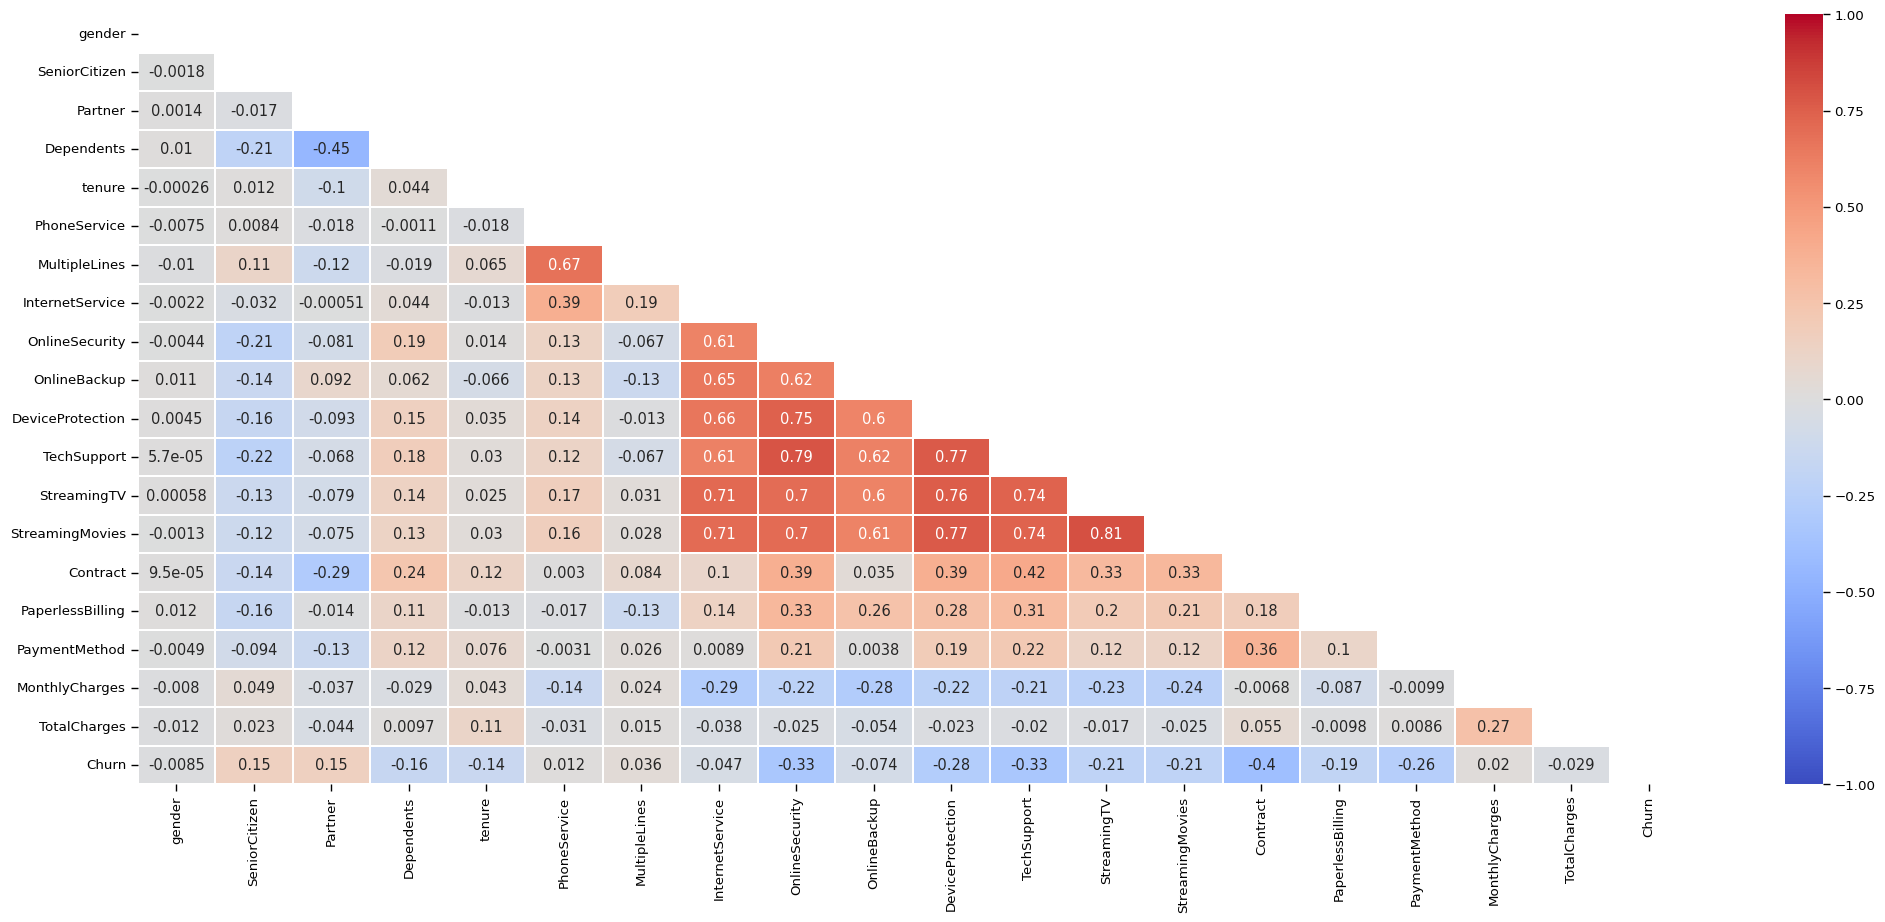

In [54]:
plt.figure(figsize=(25, 10))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

In [21]:
def object_to_int(dataframe_series): 
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series
df = df.apply(lambda x: object_to_int(x))
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)
# plt.show()
X = df.drop(columns = ['Churn'])
y = df['Churn'].values



<Figure size 1400x700 with 0 Axes>

FEATURE_ENGINEERING


In [22]:
def distplot(feature, frame, color='r'): #FEAT_ENGG
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)

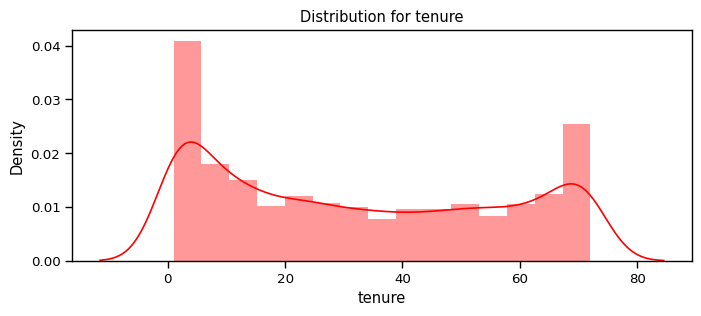

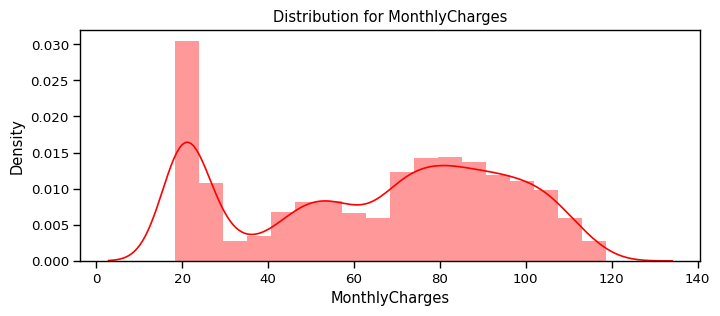

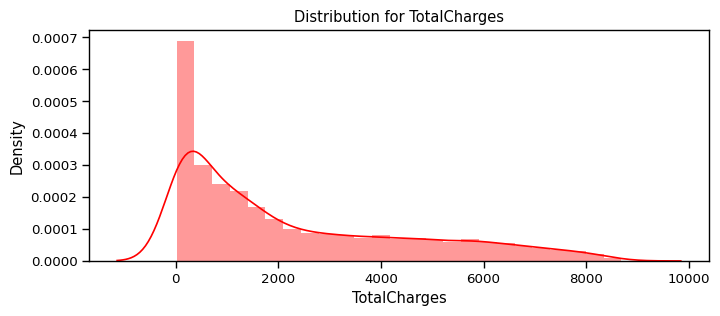

In [23]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']
for feat in num_cols: distplot(feat, df)

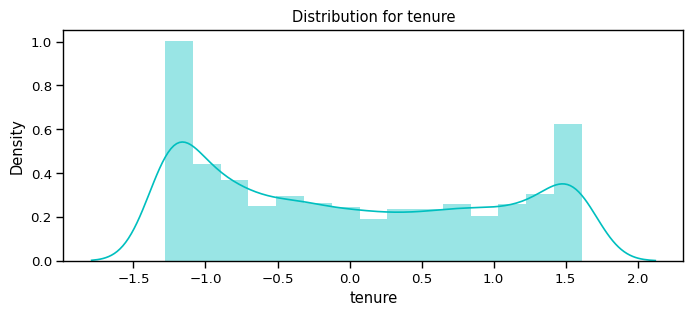

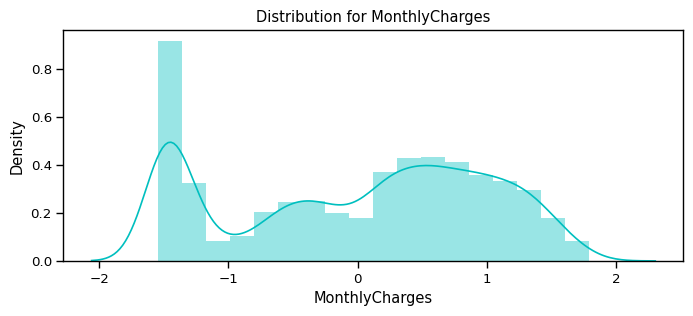

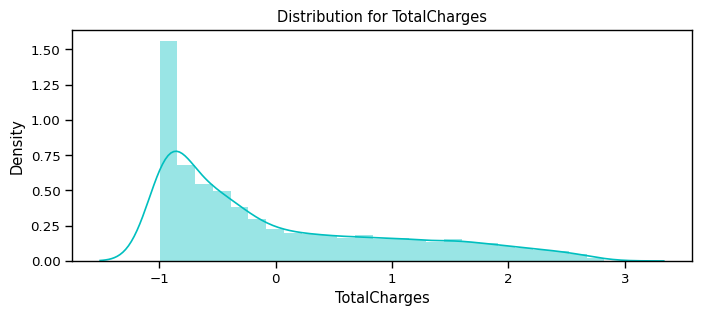

In [24]:
df_std = pd.DataFrame(StandardScaler().fit_transform(df[num_cols].astype('float64')),
                       columns=num_cols)
for feat in numerical_cols: distplot(feat, df_std, color='c')
#feat_engg

SPLITTING INTO TRAIN_TEST

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.1, random_state = 40, stratify=y)


TRANSFORMATION

In [37]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

SPLITING TEST SET FOR SHAP VISUALIZATION

In [38]:
n = 25
X_test_sampled = X_test.sample(n=n, random_state=42)

MODEL PREDICTION


KNN

KNN_ACCURACY 0.78125
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       517
           1       0.60      0.52      0.56       187

    accuracy                           0.78       704
   macro avg       0.72      0.70      0.71       704
weighted avg       0.77      0.78      0.78       704



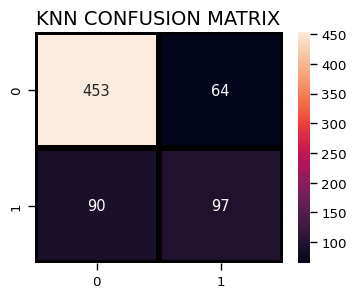

In [40]:
# Define the number of neighbors for KNN
n_neighbors = 11

# Initialize the KNN model with the specified number of neighbors
knn_model = KNeighborsClassifier(n_neighbors=n_neighbors)

# Train the KNN model using the training data
knn_model.fit(X_train, y_train)

# Make predictions on the test set
predicted_y = knn_model.predict(X_test)

# Calculate the accuracy of the model on the test set
accuracy_knn = knn_model.score(X_test, y_test)
print("KNN Accuracy:", accuracy_knn)

# Print a classification report showing precision, recall, F1-score, and support
print(classification_report(y_test, predicted_y))

# Plot a confusion matrix to visualize performance
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predicted_y),
            annot=True, fmt="d", linecolor="k", linewidths=3)
plt.title("KNN Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Initialize JavaScript for SHAP (SHapley Additive exPlanations)
shap.initjs()

# Sample background data for SHAP explanation (optional)
background = shap.sample(X_train, nsamples=100)

# Initialize a KernelExplainer with the KNN model's predict_proba function
explainer = shap.KernelExplainer(knn_model.predict_proba, background)

# Generate SHAP values for a single instance in the test set
shap_values = explainer.shap_values(X_test.iloc[0, :])

# Visualize the SHAP values as a force plot for the single instance
shap.force_plot(explainer.expected_value[0], shap_values[:, 0], X_test.iloc[0, :])

# Generate SHAP values for a sampled set of instances in the test set
shap_values = explainer.shap_values(X_test_sampled)

# Visualize the aggregated SHAP values as a force plot
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test_sampled)

SVC

SVM ACCURACY IS 0.7954545454545454
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       517
           1       0.67      0.46      0.54       187

    accuracy                           0.80       704
   macro avg       0.75      0.69      0.71       704
weighted avg       0.78      0.80      0.78       704



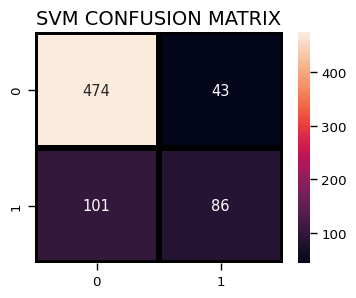

100%|██████████| 25/25 [05:37<00:00, 13.51s/it]


In [42]:
svc_model = SVC(random_state=1,probability=True)
svc_model.fit(X_train,y_train)
predict_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test,y_test)
print("SVM ACCURACY IS", accuracy_svc)
print(classification_report(y_test, predict_y))


plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,predict_y),
            annot=True,fmt="d",linecolor="k",linewidths=3)
plt.title("SVM CONFUSION MATRIX",fontsize = 14)
plt.show()
# background = shap.sample(X_train, nsamples=100)

# explain all the predictions in the test set
explainer = shap.KernelExplainer(svc_model.predict_proba, X_test_sampled)
shap_values = explainer.shap_values(X_test_sampled)
# this is multiclass so we only visualize the contributions to first class (hence index 0)
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test_sampled)

LOGISTIC REGRESSION

Logistic Regression accuracy is : 0.8039772727272727
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       517
           1       0.65      0.56      0.60       187

    accuracy                           0.80       704
   macro avg       0.75      0.73      0.74       704
weighted avg       0.80      0.80      0.80       704



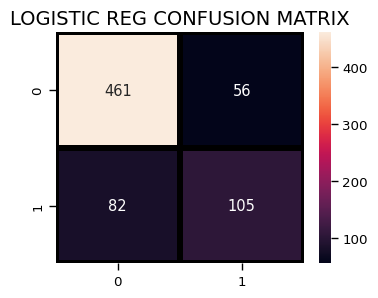

100%|██████████| 25/25 [00:05<00:00,  4.61it/s]


In [43]:

lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
lr_pred= lr_model.predict(X_test)
accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)
print(classification_report(y_test,lr_pred))


plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,lr_pred),
            annot=True,fmt="d",linecolor="k",linewidths=3)
plt.title("LOGISTIC REG CONFUSION MATRIX",fontsize = 14)
plt.show()
# background = shap.sample(X_train, nsamples=100)

explainer = shap.KernelExplainer(lr_model.predict_proba, X_test_sampled)
shap_values = explainer.shap_values(X_test_sampled)
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test_sampled)

RANDOM FOREST

ACCURACY_RF 0.8082386363636364
              precision    recall  f1-score   support

           0       0.83      0.92      0.88       517
           1       0.70      0.49      0.58       187

    accuracy                           0.81       704
   macro avg       0.77      0.71      0.73       704
weighted avg       0.80      0.81      0.80       704



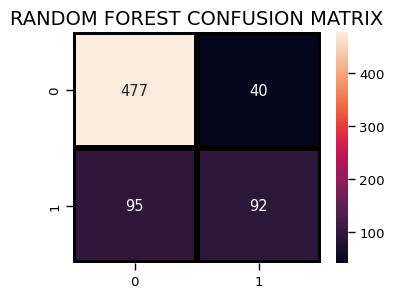

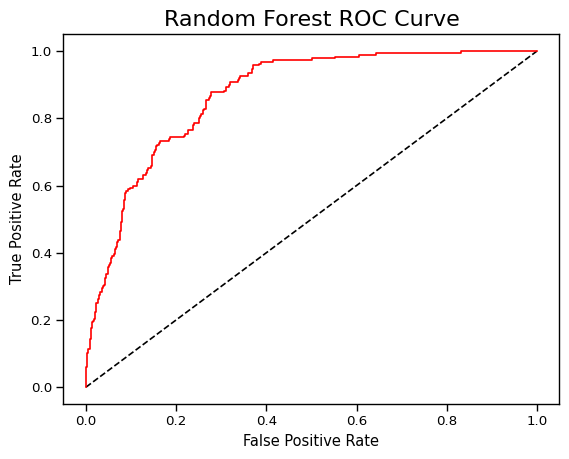

100%|██████████| 25/25 [00:13<00:00,  1.89it/s]


In [44]:
model_rf = RandomForestClassifier(n_estimators=500, oob_score=True, n_jobs=-1,
                                  random_state=50, max_features="sqrt",
                                  max_leaf_nodes=30)
model_rf.fit(X_train,y_train)
predicty = model_rf.predict(X_test)
accuracy_rf = model_rf.score(X_test,y_test)
print("ACCURACY_RF",accuracy_rf)
print(classification_report(y_test,predicty))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,predicty),
            annot=True,fmt="d",linecolor="k",linewidths=3)
plt.title("RANDOM FOREST CONFUSION MATRIX",fontsize = 14)
plt.show()

y_rfpred_prob = model_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Random Forest',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve',fontsize=16)
plt.show()
# background = shap.sample(X_train, nsamples=100)

explainer = shap.KernelExplainer(model_rf.predict_proba, X_test_sampled)
shap_values = explainer.shap_values(X_test_sampled)
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test_sampled)

DECISON TREE

Decision Tree accuracy is : 0.7144886363636364
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       517
           1       0.46      0.49      0.48       187

    accuracy                           0.71       704
   macro avg       0.64      0.64      0.64       704
weighted avg       0.72      0.71      0.72       704



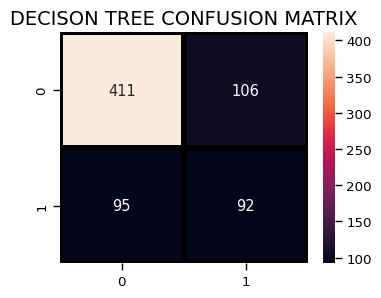

100%|██████████| 25/25 [00:05<00:00,  4.54it/s]


In [46]:

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
predictdt_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test,y_test)
print("Decision Tree accuracy is :",accuracy_dt)
print(classification_report(y_test, predictdt_y))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,predictdt_y),
            annot=True,fmt="d",linecolor="k",linewidths=3)
plt.title("DECISON TREE CONFUSION MATRIX",fontsize = 14)
plt.show()

# background = shap.sample(X_train,n_samples = 100)
explainer = shap.KernelExplainer(dt_model.predict_proba,X_test_sampled)
shap_values = explainer.shap_values(X_test_sampled)
shap.force_plot(explainer.expected_value[0],shap_values[...,0],X_test_sampled)



GRADIENT BOOSTING

Gradient Boosting Classifier 0.8025568181818182
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       517
           1       0.66      0.53      0.59       187

    accuracy                           0.80       704
   macro avg       0.75      0.72      0.73       704
weighted avg       0.79      0.80      0.80       704



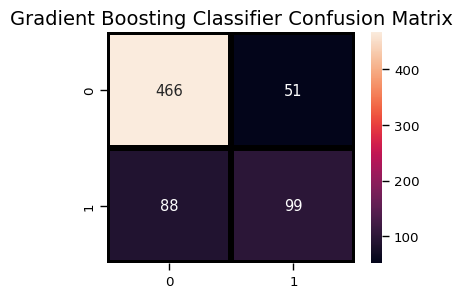

100%|██████████| 25/25 [00:06<00:00,  3.91it/s]


In [47]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting Classifier", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, gb_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("Gradient Boosting Classifier Confusion Matrix",fontsize=14)
plt.show()

# background = shap.sample(X_train,n_samples = 100)
explainer = shap.KernelExplainer(gb.predict_proba,X_test_sampled)
shap_values = explainer.shap_values(X_test_sampled)
shap.force_plot(explainer.expected_value[0],shap_values[...,0],X_test_sampled)

GRID SEARCH METHOD

Best Accuracy with GrioSearch 0.8036120591581343


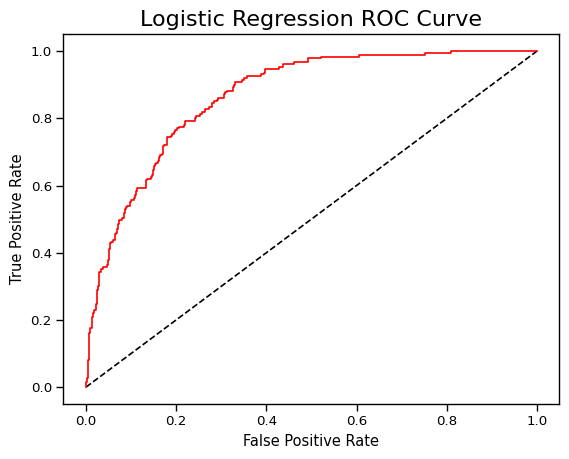

In [48]:
C = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]
scores = []
logit = LogisticRegression()

for choice in C:
  logit.set_params(C=choice) 
  logit.fit(X, y)
  scores.append(logit.score(X, y))
print("Best Accuracy with GrioSearch",max(scores))

y_pred_prob = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve',fontsize=16)
plt.show()

RANDOM SEARCH METHOD

In [49]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

max_iter = range(100, 500)
solver = ['lbfgs', 'newton-cg', 'liblinear']
warm_start = [True, False]
C = np.arange(0, 1, 0.01)
random_grid ={
    'max_iter' : max_iter,
    'warm_start' : warm_start,
    'solver' : solver,
    'C' : C,
}
random_estimator = RandomizedSearchCV(estimator = lr_model,
                                   param_distributions = random_grid,
                                   n_iter = 100,
                                   scoring = 'accuracy',
                                   n_jobs = -1,
                                   verbose = 1, 
                                   random_state = 1,
                                  )
random_estimator.fit(X_train, y_train)

random_estimator.best_params_
best_estimator = random_estimator.best_estimator_
best_estimator.fit(X_train, y_train)
pred = best_estimator.predict(X_test)
accuracy_score(pred, y_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


0.8082386363636364

VOTING CLASSIFFIER:FOR HELPING BUISSNESS FOR CHURN ANALYSIS

Final Accuracy Score 
0.7926136363636364
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       517
           1       0.64      0.50      0.56       187

    accuracy                           0.79       704
   macro avg       0.74      0.70      0.71       704
weighted avg       0.78      0.79      0.78       704



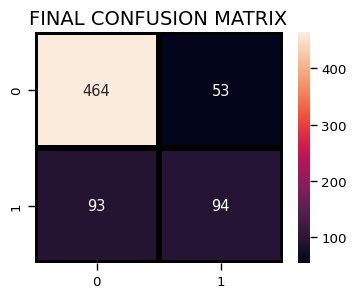

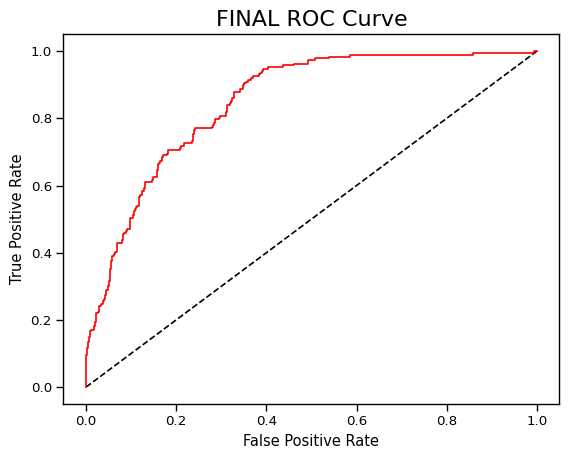

100%|██████████| 25/25 [05:54<00:00, 14.18s/it]


In [57]:
from sklearn.ensemble import VotingClassifier
clf1 = GradientBoostingClassifier()
clf2 = LogisticRegression()
clf3 = AdaBoostClassifier()
clf4 = RandomForestClassifier()
clf5 = DecisionTreeClassifier()
clf6 = SVC(probability=True)
eclf1 = VotingClassifier(estimators=[('gbc', clf1), ('lr', clf2), ('abc', clf3),('rf',clf4),('Dt',clf5),('svc',clf6)], voting='soft')
eclf1.fit(X_train, y_train)
predictions = eclf1.predict(X_test)
print("Final Accuracy Score ")
print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predictions),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("FINAL CONFUSION MATRIX",fontsize=14)
plt.show()

y_pred_prob = eclf1.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FINAL ROC Curve',fontsize=16)
plt.show()
explainer = shap.KernelExplainer(eclf1.predict_proba, X_test_sampled)
shap_values = explainer.shap_values(X_test_sampled)
# this is multiclass so we only visualize the contributions to first class (hence index 0)
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test_sampled)

#helping of company 